In [1090]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from scipy.stats import expon, norm, kstest, chi2, f_oneway, pearsonr, chisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [1073]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Parametry modelu (z symulacji)
LAMBDA = 8    # pacjenci na godzinę
MU = 3        # pacjenci obsłużeni przez lekarza na godzinę  
C = 3         # liczba lekarzy

In [1074]:
# Wczytanie danych
df = pd.read_csv('wyniki_symulacji.csv')

### Testy normalności czasów oczekiwania

Hipotezy:
- H₀ (hipoteza zerowa): Czasy oczekiwania mają rozkład normalny
- H₁ (hipoteza alternatywna): Czasy oczekiwania NIE mają rozkładu normalnego

In [1075]:
# Test Shapiro-Wilka
stat_shapiro, p_shapiro = stats.shapiro(df['Czas_oczekiwania'])
print(f"\n1) Test Shapiro-Wilka:")
print(f"   - Statystyka testowa W: {stat_shapiro:.4f}")
print(f"   - p-wartość: {p_shapiro:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_shapiro < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Czasy oczekiwania {'NIE MAJĄ' if p_shapiro < 0.05 else 'MAJĄ'} rozkładu normalnego")


1) Test Shapiro-Wilka:
   - Statystyka testowa W: 0.8064
   - p-wartość: 0.0000
   - Decyzja: ODRZUCAMY H₀
   - Interpretacja: Czasy oczekiwania NIE MAJĄ rozkładu normalnego


In [1076]:
# Test Kołmogorowa-Smirnowa
stat_ks, p_ks = stats.kstest(df['Czas_oczekiwania'], 'norm', 
                             args=(df['Czas_oczekiwania'].mean(), 
                                   df['Czas_oczekiwania'].std()))
print(f"\n2) Test Kołmogorowa-Smirnowa:")
print(f"   - Statystyka testowa D: {stat_ks:.4f}")
print(f"   - p-wartość: {p_ks:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_ks < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Czasy oczekiwania {'NIE MAJĄ' if p_ks < 0.05 else 'MAJĄ'} rozkładu normalnego")


2) Test Kołmogorowa-Smirnowa:
   - Statystyka testowa D: 0.2008
   - p-wartość: 0.0000
   - Decyzja: ODRZUCAMY H₀
   - Interpretacja: Czasy oczekiwania NIE MAJĄ rozkładu normalnego


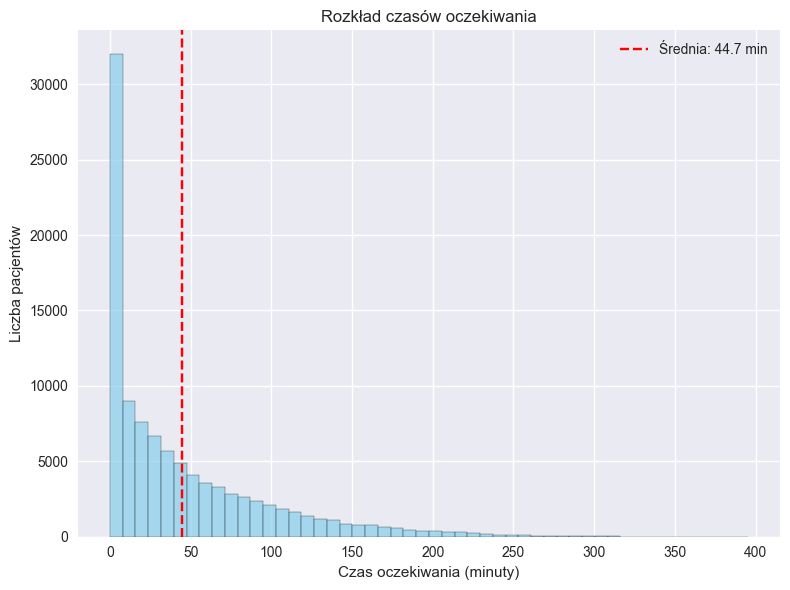

In [1077]:
plt.show()
plt.figure(figsize=(8, 6))
plt.hist(df['Czas_oczekiwania'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Rozkład czasów oczekiwania')
plt.xlabel('Czas oczekiwania (minuty)')
plt.ylabel('Liczba pacjentów')
plt.axvline(df['Czas_oczekiwania'].mean(), color='red', linestyle='--', 
            label=f'Średnia: {df["Czas_oczekiwania"].mean():.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

### Test zgodności z teoretycznym rozkładem czasów oczekiwania

In [1078]:
# # Obliczenia teoretyczne
# rho = LAMBDA / (C * MU)  # współczynnik wykorzystania
# a = LAMBDA / MU  # intensywność ruchu

# print(rho)

# # Prawdopodobieństwo Erlanga C
# def erlang_c(c, a):
#     """Oblicza prawdopodobieństwo Erlanga C"""
#     sum_term = sum([(a**n) / np.math.factorial(n) for n in range(c)])
#     pc_term = (a**c) / (np.math.factorial(c) * (1 - rho))
#     p0 = 1 / (sum_term + pc_term)
#     pc = pc_term * p0
#     return pc

# pc = erlang_c(C, a)

# # Teoretyczny średni czas oczekiwania w kolejce (wzór Little'a)
# Wq_theoretical = (pc / (C * MU - LAMBDA)) * 60  # w minutach



# print(f"- Teoretyczny średni czas oczekiwania: {Wq_theoretical:.2f} minut")
# print(f"- Empiryczny średni czas oczekiwania: {df['Czas_oczekiwania'].mean():.2f} minut")

# print("\nHIPOTEZY:")
# print(f"H₀: Średni czas oczekiwania = {Wq_theoretical:.2f} minut (wartość teoretyczna)")
# print(f"H₁: Średni czas oczekiwania ≠ {Wq_theoretical:.2f} minut")
# print("\nPoziom istotności: α = 0.05")

# # Test t-Studenta dla jednej próby
# t_stat, p_value = stats.ttest_1samp(df['Czas_oczekiwania'], popmean=32)
# print(f"\nTest t-Studenta dla jednej próby:")
# print(f"- Statystyka testowa t: {t_stat:.4f}")
# print(f"- p-wartość: {p_value:.4f}")
# print(f"- Decyzja: {'ODRZUCAMY H₀' if p_value < 0.05 else 'NIE ODRZUCAMY H₀'}")
# print(f"- Interpretacja: Średni czas oczekiwania {'NIE JEST' if p_value < 0.05 else 'JEST'} zgodny z modelem teoretycznym")

### Testy jednorodności - porównanie efektywności lekarzy

In [1079]:
print("\nHIPOTEZY:")
print("H₀: Średnie czasy oczekiwania są równe dla wszystkich lekarzy")
print("    (μ₁ = μ₂ = ... = μc)")
print("H₁: Przynajmniej jeden lekarz ma inną średnią czasów oczekiwania")
print("    (istnieją i,j takie że μᵢ ≠ μⱼ)")
print("\nPoziom istotności: α = 0.05")

# Statystyki opisowe per lekarz
print("\nStatystyki per lekarz:")
doctor_stats = df.groupby('Lekarz')['Czas_oczekiwania'].agg(['count', 'mean', 'std', 'min', 'max'])
print(doctor_stats)

# Przygotowanie danych
waiting_times_by_doctor = [group['Czas_oczekiwania'].values 
                          for _, group in df.groupby('Lekarz')]

# Test ANOVA (parametryczny)
f_stat, p_anova = f_oneway(*waiting_times_by_doctor)
print(f"\n1) Test ANOVA (analiza wariancji):")
print(f"   - Statystyka F: {f_stat:.4f}")
print(f"   - p-wartość: {p_anova:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_anova < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Lekarze {'RÓŻNIĄ SIĘ' if p_anova < 0.05 else 'NIE RÓŻNIĄ SIĘ'} pod względem średnich czasów oczekiwania")



HIPOTEZY:
H₀: Średnie czasy oczekiwania są równe dla wszystkich lekarzy
    (μ₁ = μ₂ = ... = μc)
H₁: Przynajmniej jeden lekarz ma inną średnią czasów oczekiwania
    (istnieją i,j takie że μᵢ ≠ μⱼ)

Poziom istotności: α = 0.05

Statystyki per lekarz:
        count       mean        std  min         max
Lekarz                                              
1       33478  44.473476  53.038527  0.0  394.647526
2       33724  45.001450  53.644798  0.0  395.350787
3       33280  44.696600  53.271052  0.0  378.346392

1) Test ANOVA (analiza wariancji):
   - Statystyka F: 0.8305
   - p-wartość: 0.4358
   - Decyzja: NIE ODRZUCAMY H₀
   - Interpretacja: Lekarze NIE RÓŻNIĄ SIĘ pod względem średnich czasów oczekiwania


In [1080]:
h_stat, p_kruskal = stats.kruskal(*waiting_times_by_doctor)
print(f"\n2) Test Kruskala-Wallisa (nieparametryczny):")
print(f"   - Statystyka H: {h_stat:.4f}")
print(f"   - p-wartość: {p_kruskal:.4f}")
print(f"   - Decyzja: {'ODRZUCAMY H₀' if p_kruskal < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"   - Interpretacja: Lekarze {'RÓŻNIĄ SIĘ' if p_kruskal < 0.05 else 'NIE RÓŻNIĄ SIĘ'} pod względem rozkładów czasów oczekiwania")


2) Test Kruskala-Wallisa (nieparametryczny):
   - Statystyka H: 1.3009
   - p-wartość: 0.5218
   - Decyzja: NIE ODRZUCAMY H₀
   - Interpretacja: Lekarze NIE RÓŻNIĄ SIĘ pod względem rozkładów czasów oczekiwania


### Test zgodności czasów obsługi z rozkładem wykładniczym

In [1086]:
df['Czas_obslugi'] = df['Czas_zakonczenia_badania'] - df['Czas_rozpoczecia_badania']

print("\nHIPOTEZY:")
print("H₀: Czasy obsługi mają rozkład wykładniczy z parametrem μ = 3 pacjentów/godzinę")
print("H₁: Czasy obsługi NIE mają rozkładu wykładniczego")
print("\nPoziom istotności: α = 0.05")

theoretical_mean = 60 / MU  

ks_stat, ks_p = kstest(df['Czas_obslugi'], 'expon' , args=(0, 1/MU))
print(f"\nTest Kołmogorowa-Smirnowa:")
print(f"- Statystyka testowa D: {ks_stat:.4f}")
print(f"- p-wartość: {ks_p:.4f}")
print(f"- Decyzja: {'ODRZUCAMY H₀' if ks_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Czasy obsługi {'NIE MAJĄ' if ks_p < 0.05 else 'MAJĄ'} rozkładu wykładniczego")
    


HIPOTEZY:
H₀: Czasy obsługi mają rozkład wykładniczy z parametrem μ = 3 pacjentów/godzinę
H₁: Czasy obsługi NIE mają rozkładu wykładniczego

Poziom istotności: α = 0.05

Test Kołmogorowa-Smirnowa:
- Statystyka testowa D: 0.9168
- p-wartość: 0.0000
- Decyzja: ODRZUCAMY H₀
- Interpretacja: Czasy obsługi NIE MAJĄ rozkładu wykładniczego


In [1087]:
interarrival_times = []
    
for day, day_data in df.groupby('Dzien'):
    day_sorted = day_data.sort_values('Czas_przyjscia')
        
    if 'Czas_przyjscia_exact' in day_sorted.columns:
        arrival_times = day_sorted['Czas_przyjscia_exact'].values
    else:
        arrival_times = day_sorted['Czas_przyjscia'].values
        
    if len(arrival_times) > 1:
        day_interarrival = np.diff(arrival_times)
        interarrival_times.extend(day_interarrival)
    
interarrival_times = np.array(interarrival_times)
    
    
mean_interarrival = np.mean(interarrival_times)
std_interarrival = np.std(interarrival_times)
    
theoretical_mean = 60 / LAMBDA  
theoretical_std = 60 / LAMBDA   


print("\nHIPOTEZY:")
print("H₀: Czasy między przybyciami mają rozkład wykładniczy")
print("H₁: Czasy między przybyciami NIE mają rozkładu wykładniczego")
print("\nPoziom istotności: α = 0.05")

ks_stat, ks_p = kstest(interarrival_times, 'expon', args=(0, theoretical_mean))
    
print(f"\nTest Kołmogorowa-Smirnowa:")
print(f"- Statystyka testowa D: {ks_stat:.4f}")
print(f"- p-wartość: {ks_p:.4f}")
print(f"- Poziom istotności: α = 0.05")
print(f"- Decyzja: {'ODRZUCAMY H₀' if ks_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Czasy między przybyciami {'NIE MAJĄ' if ks_p < 0.05 else 'MAJĄ'} rozkład wykładniczy")


HIPOTEZY:
H₀: Czasy między przybyciami mają rozkład wykładniczy
H₁: Czasy między przybyciami NIE mają rozkładu wykładniczego

Poziom istotności: α = 0.05

Test Kołmogorowa-Smirnowa:
- Statystyka testowa D: 0.0015
- p-wartość: 0.9827
- Poziom istotności: α = 0.05
- Decyzja: NIE ODRZUCAMY H₀
- Interpretacja: Czasy między przybyciami MAJĄ rozkład wykładniczy


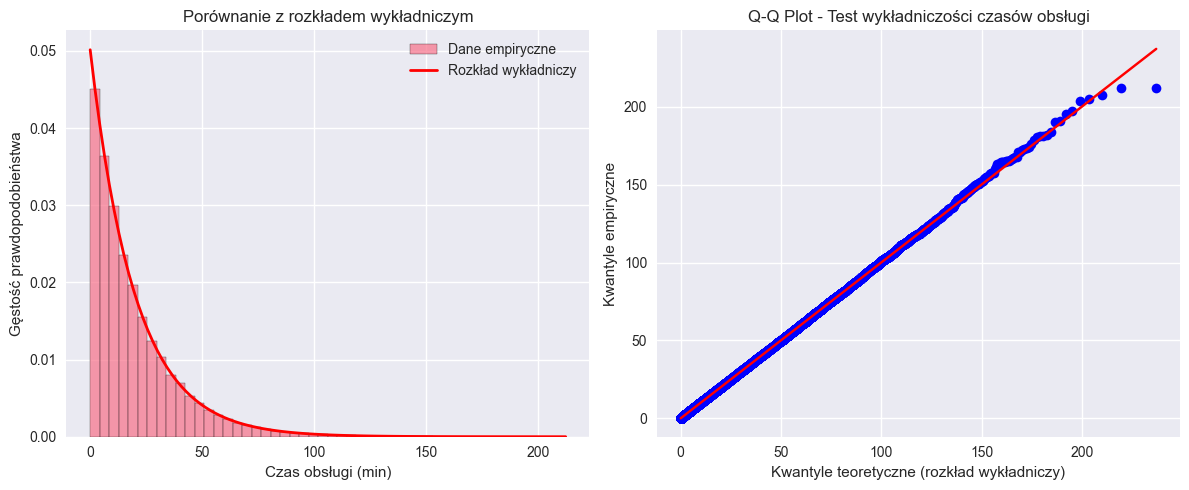

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram z dopasowanym rozkładem wykładniczym
ax1.hist(df['Czas_obslugi'], bins=50, density=True, alpha=0.7, 
         edgecolor='black', label='Dane empiryczne')
x = np.linspace(0, df['Czas_obslugi'].max(), 100)
ax1.plot(x, expon.pdf(x, scale=df['Czas_obslugi'].mean()), 
         'r-', lw=2, label='Rozkład wykładniczy')
ax1.set_xlabel('Czas obsługi (min)')
ax1.set_ylabel('Gęstość prawdopodobieństwa')
ax1.set_title('Porównanie z rozkładem wykładniczym')
ax1.legend()

# Q-Q plot dla rozkładu wykładniczego
stats.probplot(df['Czas_obslugi'], dist=expon, 
               sparams=(0, df['Czas_obslugi'].mean()), plot=ax2)
ax2.set_title('Q-Q Plot - Test wykładniczości czasów obsługi')
ax2.set_xlabel('Kwantyle teoretyczne (rozkład wykładniczy)')
ax2.set_ylabel('Kwantyle empiryczne')

plt.tight_layout()
plt.show()

### Test chi-kwadrat dla rozkładu długości kolejki

In [ ]:
print("\nHIPOTEZY:")
print("H₀: Długości kolejek w momencie przyjścia mają rozkład jednostajny")
print("H₁: Długości kolejek w momencie przyjścia nie mają rozkładu jednostajnego")

dlugosc_kolejki = df["Dlugosc_kolejki_w_momencie_przyjscia"]
obserwowane = dlugosc_kolejki.value_counts().sort_index()

spodziewane = [len(dlugosc_kolejki) / len(obserwowane)] * len(obserwowane)


chi2_stat, chi2_p = chisquare(f_obs=obserwowane, f_exp=spodziewane)
print("Test chi-kwadrat:")
print(f"χ² = {chi2_stat:.4f}, p-wartość = {chi2_p:.5f}")
if chi2_p < 0.05:
    print("Odrzucamy hipotezę zerową o jednorodności rozkładu długości kolejek.")
else:
    print("Brak podstaw do odrzucenia hipotezy zerowej o jednorodności rozkładu długości kolejek.")

print(f"- Decyzja: {'ODRZUCAMY H₀' if chi2_p < 0.05 else 'NIE ODRZUCAMY H₀'}")
print(f"- Interpretacja: Długości kolejek w momencie przyjścia {'NIE MAJĄ' if chi2_p < 0.05 else 'MAJĄ'} rozkładu jednostajnego")


HIPOTEZY:
H₀: Długości kolejek w momencie przyjścia mają rozkład jednostajny
H₁: Długości kolejek w momencie przyjścia nie mają rozkładu jednostajnego
Test chi-kwadrat:
χ² = 734481.0123, p-wartość = 0.00000
Odrzucamy hipotezę zerową o jednorodności rozkładu długości kolejek.
- Decyzja: ODRZUCAMY H₀
- Interpretacja: Długości kolejek w momencie przyjścia NIE MAJĄ rozkład jednostajny
